In [2]:
import matplotlib.pyplot as plt

In [3]:
import numpy as np

In [4]:
from pyiron_base import Project

In [5]:
from pyiron_glass import (
    melt_quench_simulation,
    generate_potential,
    get_ase_structure,
    get_structure_dict,
)

In [6]:
pr = Project("test")

In [7]:


atoms_dict = get_structure_dict(
    comp="0.25CaO-0.25Al2O3-0.50SiO2", 
    n_molecules=200, 
    density=2.69*1.0, 
    min_distance=1.8, 
    max_attempts_per_atom = 10000,
    pyiron_project=pr,
)
structure = get_ase_structure(atoms_dict=atoms_dict, pyiron_project=pr,)
potential = generate_potential(atoms_dict=atoms_dict, pyiron_project=pr,)
delayed = melt_quench_simulation(
    structure=structure, 
    potential=potential,
    temperature_high=5000,
    temperature_low=300,
    n_print=1000,
    working_directory="lmp_tmp_directory",
    heating_rate=int(1e14),
    cooling_rate=int(1e14),
    pyiron_project=pr,
)

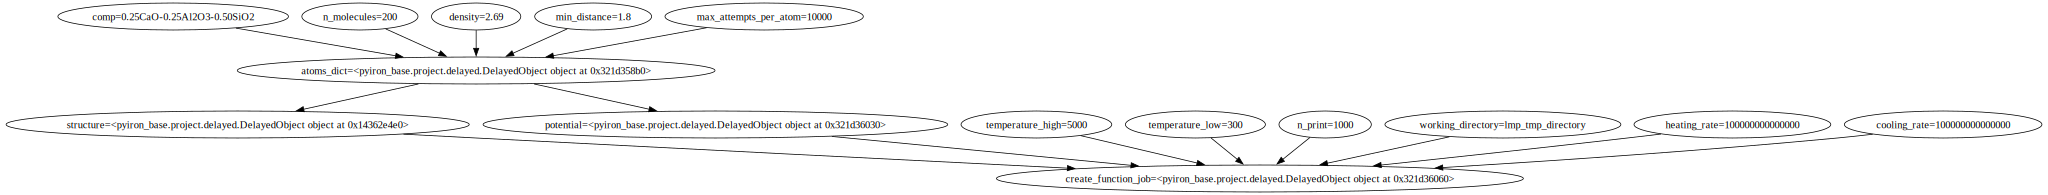

In [8]:
delayed.draw()

In [9]:
result = delayed.pull()

The job get_ase_structure_c6edc0c93e1559d3f94c8e34e0f7675b was saved and received the ID: 319
The job generate_potential_5688a46c49bc9b969a506dee8d4d22ee was saved and received the ID: 320
The job melt_quench_simulation_a8c843181ebf67c9fc4defcf9b9c7de9 was saved and received the ID: 321


/opt/homebrew/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(fname, key=rootpath)
/opt/homebrew/lib/python3.12/site-packages/h5io/_h5io.py:72: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(file_name, key=rootpath)
/opt/homebrew/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='o

300.17024000714855


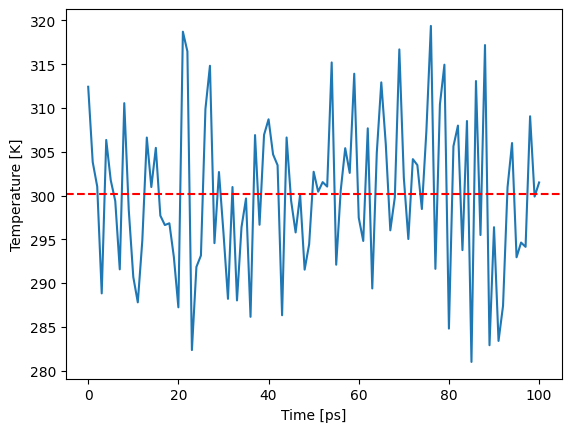

In [10]:
plt.plot(result["steps"]*1e-3, result["temperature"])
plt.axhline(np.mean(result["temperature"]), color="red", linestyle="--")
print(np.mean(result["temperature"]))
plt.xlabel("Time [ps]")
plt.ylabel("Temperature [K]");